# Business Understanding
Latar Belakang
...

# Business Question
1. Bagaimana distribusi karakteristik mahasiswa berdasarkan jurusan, bidang minat, soft skill, pengalaman, dan sertifikasi yang dimiliki?
2. Karier apa yang paling banyak direkomendasikan berdasarkan karakteristik mahasiswa dalam dataset?
3. Bagaimana hubungan antara latar belakang akademik (jurusan) dan rekomendasi karier yang diberikan?

# CAPSTONE PROJECT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# LOAD DATASET

In [ ]:
df = pd.read_csv('/content/Data Karir dan Jurusan.csv')

print("Jumlah data awal:", len(df))
df.head()

Jumlah data awal: 51000


,Jurusan,IPK,Bidang_Minat,Keahlian_1,Keahlian_2,Keahlian_3,Kepemimpinan,Komunikasi,Kerja_Tim,Kreativitas,Berpikir_Kritis,Pemecahan_Masalah,Pengalaman_Magang,Pengalaman_Organisasi,Pengalaman_Kompetisi,Jumlah_Sertifikasi,Gaya_Kerja,Preferensi_Industri,Tujuan_Karier,Rekomendasi_Karier
0,Teknik Lingkungan,NaN,Manufaktur,Komunikasi,Komunikasi,Analisis Data,1.0,5.0,1.0,5.0,4.0,1.0,Ya,Ya,Ya,1.0,Onsite,Konsultan,Spesialis,Arsitek
1,Keperawatan,3.65,NaN,Desain Grafis,Komunikasi,Manajemen Proyek,5.0,3.0,1.0,2.0,4.0,3.0,Tidak,Ya,Ya,2.0,Remote,Kesehatan,Wirausaha,AI Engineer
2,Ekonomi,3.81,Konsultan,Kepemimpinan,Python,Manajemen Proyek,5.0,1.0,4.0,1.0,5.0,3.0,Tidak,Ya,Ya,0.0,Onsite,Pendidikan,Peneliti,AI Engineer
3,Kesehatan Masyarakat,3.83,NaN,Kepemimpinan,Manajemen Proyek,Machine Learning,NaN,3.0,3.0,2.0,3.0,1.0,Ya,Ya,Ya,3.0,Hybrid,Manufaktur,Manajer,Jurnalis
4,Akuntansi,3.80,Teknologi,Komunikasi,Python,Machine Learning,4.0,3.0,1.0,2.0,5.0,3.0,Ya,Tidak,Tidak,5.0,Hybrid,Keuangan,Peneliti,Software Engineer


# ANALISIS AWAL DATASET

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Jurusan                49507 non-null  object 
 1   IPK                    49477 non-null  float64
 2   Bidang_Minat           49470 non-null  object 
 3   Keahlian_1             49473 non-null  object 
 4   Keahlian_2             49470 non-null  object 
 5   Keahlian_3             49475 non-null  object 
 6   Kepemimpinan           49471 non-null  float64
 7   Komunikasi             49474 non-null  float64
 8   Kerja_Tim              49473 non-null  float64
 9   Kreativitas            49474 non-null  float64
 10  Berpikir_Kritis        49477 non-null  float64
 11  Pemecahan_Masalah      49476 non-null  float64
 12  Pengalaman_Magang      49471 non-null  object 
 13  Pengalaman_Organisasi  49468 non-null  object 
 14  Pengalaman_Kompetisi   49466 non-null  object 
 15  Ju

# CEK MISSING VALUE

In [ ]:
print(df.isnull().sum())

Jurusan                  1493
IPK                      1523
Bidang_Minat             1530
Keahlian_1               1527
Keahlian_2               1530
Keahlian_3               1525
Kepemimpinan             1529
Komunikasi               1526
Kerja_Tim                1527
Kreativitas              1526
Berpikir_Kritis          1523
Pemecahan_Masalah        1524
Pengalaman_Magang        1529
Pengalaman_Organisasi    1532
Pengalaman_Kompetisi     1534
Jumlah_Sertifikasi       1532
Gaya_Kerja               1527
Preferensi_Industri      1529
Tujuan_Karier            1533
Rekomendasi_Karier       1530
dtype: int64


# CEK DUPLIKASI

In [ ]:
print("Jumlah duplikasi:", df.duplicated().sum())

Jumlah duplikasi: 1000


# CEK STATISTIK NUMERIK

In [ ]:
df.describe()

,IPK,Kepemimpinan,Komunikasi,Kerja_Tim,Kreativitas,Berpikir_Kritis,Pemecahan_Masalah,Jumlah_Sertifikasi
count,49477.000000,49471.000000,49474.000000,49473.000000,49474.000000,49477.000000,49476.000000,49468.000000
mean,3.361322,3.000627,3.005862,2.996160,3.006165,3.003113,3.001920,2.502022
std,0.476076,1.413305,1.414216,1.416351,1.417619,1.415482,1.414219,1.713321
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,3.060000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
50%,3.370000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,3.690000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,5.200000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# BERSIHKAN SPASI BERLEBIH

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# MENYERAGAMKAN HURUF

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.title()

# PERBAIKI TYPO

In [ ]:
perbaikan_karier = {
    "Data Scintist": "Data Scientist",
    "Softwere Engineer": "Software Engineer",
    "Busines Analyst": "Business Analyst"
}

df["Rekomendasi_Karier"] = df["Rekomendasi_Karier"].replace(perbaikan_karier)

STANDARISASI NILAI YA/TIDAK

In [ ]:
kolom_ya_tidak = [
    "Pengalaman_Magang",
    "Pengalaman_Organisasi",
    "Pengalaman_Kompetisi"
]

for col in kolom_ya_tidak:
    df[col] = df[col].replace({
        "Ya":"Ya",
        "YA":"Ya",
        "ya":"Ya",
        "Tidak":"Tidak",
        "TIDAK":"Tidak",
        "tidak":"Tidak"
    })

MENGATASI MISSING VALUE

In [ ]:
numerik = df.select_dtypes(include=np.number).columns

for col in numerik:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
kategorikal = df.select_dtypes(include='object').columns

for col in kategorikal:
    df[col] = df[col].fillna(df[col].mode()[0])

# HAPUS DUPLIKASI

In [ ]:
print("Duplikasi sebelum:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplikasi sesudah:", df.duplicated().sum())

Duplikasi sebelum: 1000
Duplikasi sesudah: 0


HAPUS OUTLIER IPK

In [ ]:
print("Jumlah data sebelum:", len(df))

df = df[(df["IPK"] >= 0) & (df["IPK"] <= 4)]

print("Jumlah data sesudah:", len(df))

Jumlah data sebelum: 50000
Jumlah data sesudah: 49500


# CEKHASIL CLEANING

In [ ]:
print("\nMissing Value:")
print(df.isnull().sum())

print("\nDuplikasi:")
print(df.duplicated().sum())

print("\nUkuran Dataset:")
print(df.shape)


Missing Value:
Jurusan                  0
IPK                      0
Bidang_Minat             0
Keahlian_1               0
Keahlian_2               0
Keahlian_3               0
Kepemimpinan             0
Komunikasi               0
Kerja_Tim                0
Kreativitas              0
Berpikir_Kritis          0
Pemecahan_Masalah        0
Pengalaman_Magang        0
Pengalaman_Organisasi    0
Pengalaman_Kompetisi     0
Jumlah_Sertifikasi       0
Gaya_Kerja               0
Preferensi_Industri      0
Tujuan_Karier            0
Rekomendasi_Karier       0
dtype: int64

Duplikasi:
0

Ukuran Dataset:
(49500, 20)


# SIMPAN DATASET BERSIH

In [ ]:
df.to_csv(
    "Career_Recommendation_Cleaned.csv",
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


# DOWNLOAD HASIL

In [ ]:
from google.colab import files

files.download(
    "Career_Recommendation_Cleaned.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Gathering Data

In [ ]:
Career_Recommendation_Cleaned_df = pd.read_csv('Career_Recommendation_Cleaned.csv')
Career_Recommendation_Cleaned_df.head()

,Jurusan,IPK,Bidang_Minat,Keahlian_1,Keahlian_2,Keahlian_3,Kepemimpinan,Komunikasi,Kerja_Tim,Kreativitas,Berpikir_Kritis,Pemecahan_Masalah,Pengalaman_Magang,Pengalaman_Organisasi,Pengalaman_Kompetisi,Jumlah_Sertifikasi,Gaya_Kerja,Preferensi_Industri,Tujuan_Karier,Rekomendasi_Karier
0,Teknik Lingkungan,3.37,Manufaktur,Komunikasi,Komunikasi,Analisis Data,1.0,5.0,1.0,5.0,4.0,1.0,Ya,Ya,Ya,1.0,Onsite,Konsultan,Spesialis,Arsitek
1,Keperawatan,3.65,Nan,Desain Grafis,Komunikasi,Manajemen Proyek,5.0,3.0,1.0,2.0,4.0,3.0,Tidak,Ya,Ya,2.0,Remote,Kesehatan,Wirausaha,Ai Engineer
2,Ekonomi,3.81,Konsultan,Kepemimpinan,Python,Manajemen Proyek,5.0,1.0,4.0,1.0,5.0,3.0,Tidak,Ya,Ya,0.0,Onsite,Pendidikan,Peneliti,Ai Engineer
3,Kesehatan Masyarakat,3.83,Nan,Kepemimpinan,Manajemen Proyek,Machine Learning,3.0,3.0,3.0,2.0,3.0,1.0,Ya,Ya,Ya,3.0,Hybrid,Manufaktur,Manajer,Jurnalis
4,Akuntansi,3.80,Teknologi,Komunikasi,Python,Machine Learning,4.0,3.0,1.0,2.0,5.0,3.0,Ya,Tidak,Tidak,5.0,Hybrid,Keuangan,Peneliti,Software Engineer


# Assesing Data

In [ ]:
Career_Recommendation_Cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49500 entries, 0 to 49499
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Jurusan                49500 non-null  object 
 1   IPK                    49500 non-null  float64
 2   Bidang_Minat           49500 non-null  object 
 3   Keahlian_1             49500 non-null  object 
 4   Keahlian_2             49500 non-null  object 
 5   Keahlian_3             49500 non-null  object 
 6   Kepemimpinan           49500 non-null  float64
 7   Komunikasi             49500 non-null  float64
 8   Kerja_Tim              49500 non-null  float64
 9   Kreativitas            49500 non-null  float64
 10  Berpikir_Kritis        49500 non-null  float64
 11  Pemecahan_Masalah      49500 non-null  float64
 12  Pengalaman_Magang      49500 non-null  object 
 13  Pengalaman_Organisasi  49500 non-null  object 
 14  Pengalaman_Kompetisi   49500 non-null  object 
 15  Ju

In [ ]:
Career_Recommendation_Cleaned_df.isna().sum()

,0
Jurusan,0
IPK,0
Bidang_Minat,0
Keahlian_1,0
Keahlian_2,0
Keahlian_3,0
Kepemimpinan,0
Komunikasi,0
Kerja_Tim,0
Kreativitas,0


In [ ]:
print("Jumlah duplikasi:", Career_Recommendation_Cleaned_df.duplicated().sum())
Career_Recommendation_Cleaned_df.describe()

Jumlah duplikasi: 0


,IPK,Kepemimpinan,Komunikasi,Kerja_Tim,Kreativitas,Berpikir_Kritis,Pemecahan_Masalah,Jumlah_Sertifikasi
count,49500.000000,49500.000000,49500.000000,49500.000000,49500.000000,49500.000000,49500.000000,49500.000000
mean,3.372620,3.001010,3.004626,2.995434,3.004586,3.003192,3.002081,2.515596
std,0.355223,1.391967,1.393070,1.395352,1.395504,1.394313,1.393134,1.689575
min,2.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,3.070000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
50%,3.370000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,3.680000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
(Career_Recommendation_Cleaned_df == 'Nan').sum()

,0
Jurusan,1482
IPK,0
Bidang_Minat,1484
Keahlian_1,1485
Keahlian_2,1483
Keahlian_3,1485
Kepemimpinan,0
Komunikasi,0
Kerja_Tim,0
Kreativitas,0


# Cleaning Data

In [ ]:
Career_Recommendation_Cleaned_df.replace('Nan', np.nan, inplace=True)

In [ ]:
Career_Recommendation_Cleaned_df.isna().sum()

,0
Jurusan,1482
IPK,0
Bidang_Minat,1484
Keahlian_1,1485
Keahlian_2,1483
Keahlian_3,1485
Kepemimpinan,0
Komunikasi,0
Kerja_Tim,0
Kreativitas,0


In [ ]:
## Missing Value

In [ ]:
# Hapus missing pada target
Career_Recommendation_Cleaned_df.dropna(
    subset=['Rekomendasi_Karier'],
    inplace=True
)

# Isi missing value fitur kategorikal dengan modus
for col in Career_Recommendation_Cleaned_df.select_dtypes(include='object').columns:
    if col != 'Rekomendasi_Karier':
        Career_Recommendation_Cleaned_df[col] = (
            Career_Recommendation_Cleaned_df[col]
            .fillna(Career_Recommendation_Cleaned_df[col].mode()[0])
        )

# Cek hasil
print(Career_Recommendation_Cleaned_df.isna().sum())

Jurusan                  0
IPK                      0
Bidang_Minat             0
Keahlian_1               0
Keahlian_2               0
Keahlian_3               0
Kepemimpinan             0
Komunikasi               0
Kerja_Tim                0
Kreativitas              0
Berpikir_Kritis          0
Pemecahan_Masalah        0
Pengalaman_Magang        0
Pengalaman_Organisasi    0
Pengalaman_Kompetisi     0
Jumlah_Sertifikasi       0
Gaya_Kerja               0
Preferensi_Industri      0
Tujuan_Karier            0
Rekomendasi_Karier       0
dtype: int64


In [ ]:
(Career_Recommendation_Cleaned_df == 'Nan').sum()

,0
Jurusan,0
IPK,0
Bidang_Minat,0
Keahlian_1,0
Keahlian_2,0
Keahlian_3,0
Kepemimpinan,0
Komunikasi,0
Kerja_Tim,0
Kreativitas,0


In [ ]:
# =========================================================
# MENYIMPAN DATA CLEAN KE CSV BARU
# =========================================================

df_clean = Career_Recommendation_Cleaned_df.copy()

df_clean.to_csv(
    'New_Career_Recommendation_Cleaned.csv',
    index=False
)

print("Dataset clean berhasil disimpan!")

Dataset clean berhasil disimpan!


In [ ]:
df_clean = pd.read_csv('New_Career_Recommendation_Cleaned.csv')

df_clean.info()
df_clean.isna().sum()
df_clean.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48013 entries, 0 to 48012
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Jurusan                48013 non-null  object 
 1   IPK                    48013 non-null  float64
 2   Bidang_Minat           48013 non-null  object 
 3   Keahlian_1             48013 non-null  object 
 4   Keahlian_2             48013 non-null  object 
 5   Keahlian_3             48013 non-null  object 
 6   Kepemimpinan           48013 non-null  float64
 7   Komunikasi             48013 non-null  float64
 8   Kerja_Tim              48013 non-null  float64
 9   Kreativitas            48013 non-null  float64
 10  Berpikir_Kritis        48013 non-null  float64
 11  Pemecahan_Masalah      48013 non-null  float64
 12  Pengalaman_Magang      48013 non-null  object 
 13  Pengalaman_Organisasi  48013 non-null  object 
 14  Pengalaman_Kompetisi   48013 non-null  object 
 15  Ju

np.int64(0)

# EDA

In [ ]:
New_Career_Recommendation_Cleaned_df = pd.read_csv('New_Career_Recommendation_Cleaned.csv')
New_Career_Recommendation_Cleaned_df.describe(include="all")

,Jurusan,IPK,Bidang_Minat,Keahlian_1,Keahlian_2,Keahlian_3,Kepemimpinan,Komunikasi,Kerja_Tim,Kreativitas,Berpikir_Kritis,Pemecahan_Masalah,Pengalaman_Magang,Pengalaman_Organisasi,Pengalaman_Kompetisi,Jumlah_Sertifikasi,Gaya_Kerja,Preferensi_Industri,Tujuan_Karier,Rekomendasi_Karier
count,48013,48013.000000,48013,48013,48013,48013,48013.000000,48013.000000,48013.000000,48013.000000,48013.000000,48013.000000,48013,48013,48013,48013.000000,48013,48013,48013,48013
unique,41,NaN,10,10,10,10,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,NaN,3,10,4,14
top,Hukum,NaN,Keuangan,Analisis Data,Pemasaran Digital,Kepemimpinan,NaN,NaN,NaN,NaN,NaN,NaN,Ya,Tidak,Tidak,NaN,Hybrid,Pemerintahan,Spesialis,Arsitek
freq,2660,NaN,6181,6212,6222,6197,NaN,NaN,NaN,NaN,NaN,NaN,24772,24799,24753,NaN,17156,6261,13130,3538
mean,NaN,3.372862,NaN,NaN,NaN,NaN,2.999854,3.004145,2.994377,3.004415,3.004166,3.001416,NaN,NaN,NaN,2.515652,NaN,NaN,NaN,NaN
std,NaN,0.355306,NaN,NaN,NaN,NaN,1.392717,1.393787,1.394566,1.396257,1.393496,1.393860,NaN,NaN,NaN,1.689744,NaN,NaN,NaN,NaN
min,NaN,2.750000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,3.070000,NaN,NaN,NaN,NaN,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
50%,NaN,3.370000,NaN,NaN,NaN,NaN,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN
75%,NaN,3.680000,NaN,NaN,NaN,NaN,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN


## Analisis Jurusan Mahasiswa

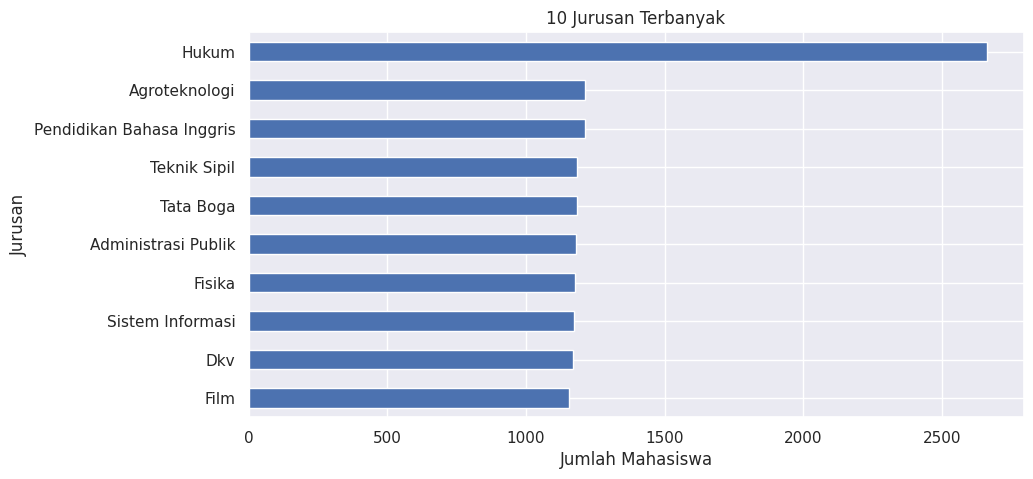

In [ ]:
plt.figure(figsize=(10,5))

Career_Recommendation_Cleaned_df['Jurusan'] \
    .value_counts() \
    .head(10) \
    .sort_values() \
    .plot(kind='barh')

plt.title('10 Jurusan Terbanyak')
plt.xlabel('Jumlah Mahasiswa')
plt.ylabel('Jurusan')
plt.show()

### Insight
Jurusan yang paling banyak muncul dalam dataset adalah jurusan hukum, sedangkan jurusan dengan jumlah mahasiswa paling sedikit pada kelompok 10 besar adalah jurusan film. Hal ini menunjukkan bahwa dataset didominasi oleh mahasiswa dari bidang studi tertentu, namun tetap mencakup berbagai latar belakang akademik yang beragam.


## Analisis Bidang Minat

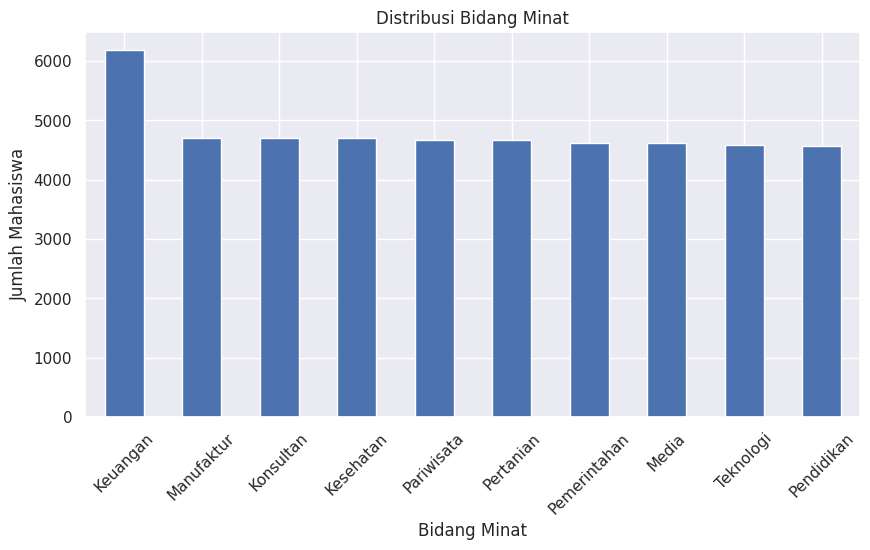

In [ ]:
plt.figure(figsize=(10,5))

Career_Recommendation_Cleaned_df['Bidang_Minat'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Distribusi Bidang Minat')
plt.xlabel('Bidang Minat')
plt.ylabel('Jumlah Mahasiswa')

plt.xticks(rotation=45)

plt.show()

### Insight
Bidang minat yang paling banyak dipilih adalah keuangan, sedangkan yang paling sedikit adalah pendidikan. Hal ini menunjukkan kecenderungan minat mahasiswa terhadap sektor tertentu yang dianggap memiliki prospek karier yang menarik.

## Analisis IPK

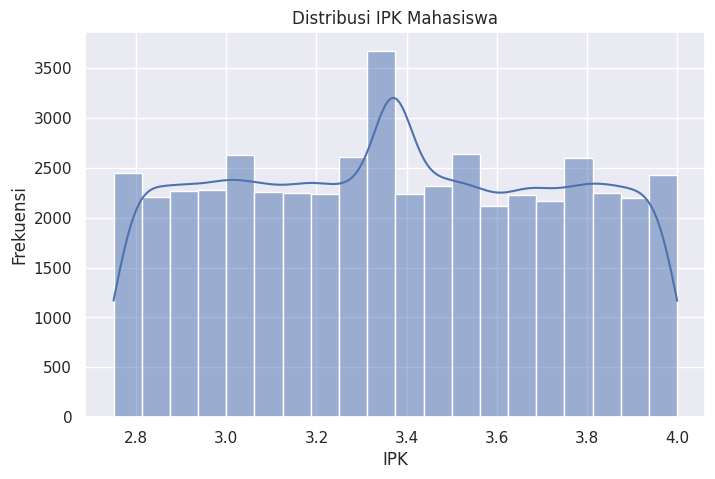

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=Career_Recommendation_Cleaned_df,
    x='IPK',
    bins=20,
    kde=True
)

plt.title('Distribusi IPK Mahasiswa')
plt.xlabel('IPK')
plt.ylabel('Frekuensi')

plt.show()

### Insight
Distribusi IPK mahasiswa berada pada rentang 2,8–4,0 dan cenderung merata. Frekuensi tertinggi berada di sekitar IPK 3,3–3,4, menunjukkan bahwa sebagian besar mahasiswa memiliki performa akademik yang baik. Distribusi yang relatif seimbang mengindikasikan tidak adanya dominasi nilai IPK pada rentang tertentu.

## Boxplot IPK

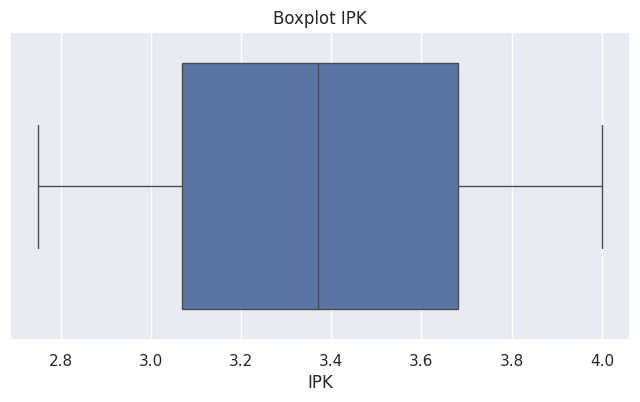

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=Career_Recommendation_Cleaned_df['IPK']
)

plt.title('Boxplot IPK')

plt.show()

### Insight
Boxplot menunjukkan bahwa nilai IPK mahasiswa berada pada rentang sekitar 2,75 hingga 4,00 dengan median sekitar 3,4. Sebanyak 50% data berada pada rentang 3,1 hingga 3,7 (IQR), yang menunjukkan variasi IPK tergolong sedang. Tidak terlihat adanya outlier, sehingga distribusi IPK relatif bersih dan tidak terdapat nilai yang menyimpang jauh dari mayoritas data. Hal ini mengindikasikan bahwa performa akademik mahasiswa dalam dataset cukup konsisten dan representatif terhadap keseluruhan populasi.

## Analisis Soft Skill

### Rata-rata Soft Skill

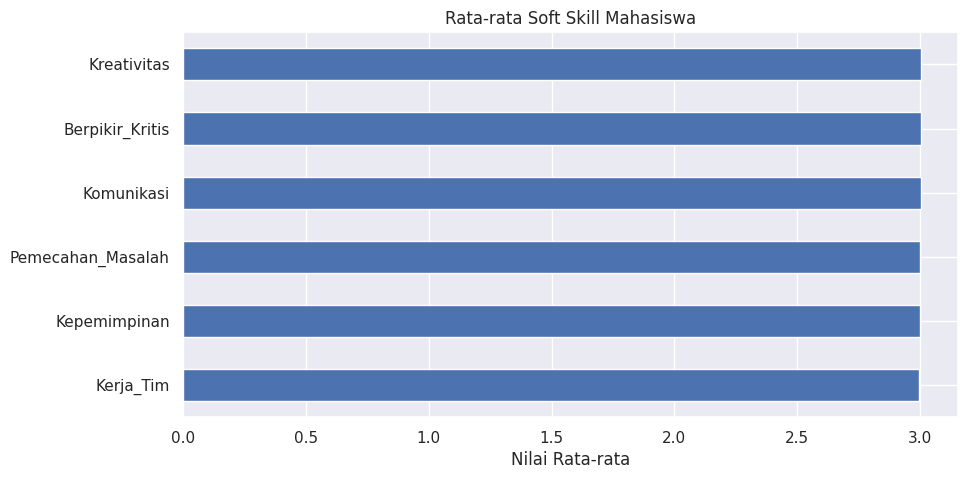

In [ ]:
softskill = [
    'Kepemimpinan',
    'Komunikasi',
    'Kerja_Tim',
    'Kreativitas',
    'Berpikir_Kritis',
    'Pemecahan_Masalah'
]

plt.figure(figsize=(10,5))

Career_Recommendation_Cleaned_df[softskill] \
    .mean() \
    .sort_values() \
    .plot(kind='barh')

plt.title('Rata-rata Soft Skill Mahasiswa')
plt.xlabel('Nilai Rata-rata')

plt.show()

### Insight
Grafik menunjukkan bahwa rata-rata seluruh aspek soft skill mahasiswa, yaitu Kerja Tim, Kepemimpinan, Pemecahan Masalah, Komunikasi, Berpikir Kritis, dan Kreativitas, berada pada nilai yang hampir identik (sekitar 3,0). Hal ini mengindikasikan bahwa mahasiswa memiliki tingkat penguasaan soft skill yang relatif seimbang tanpa adanya kesenjangan yang signifikan antar kemampuan. Dengan demikian, tidak terdapat satu soft skill yang secara mencolok lebih unggul maupun lebih rendah dibandingkan yang lainnya.

### Distribusi Soft Skill

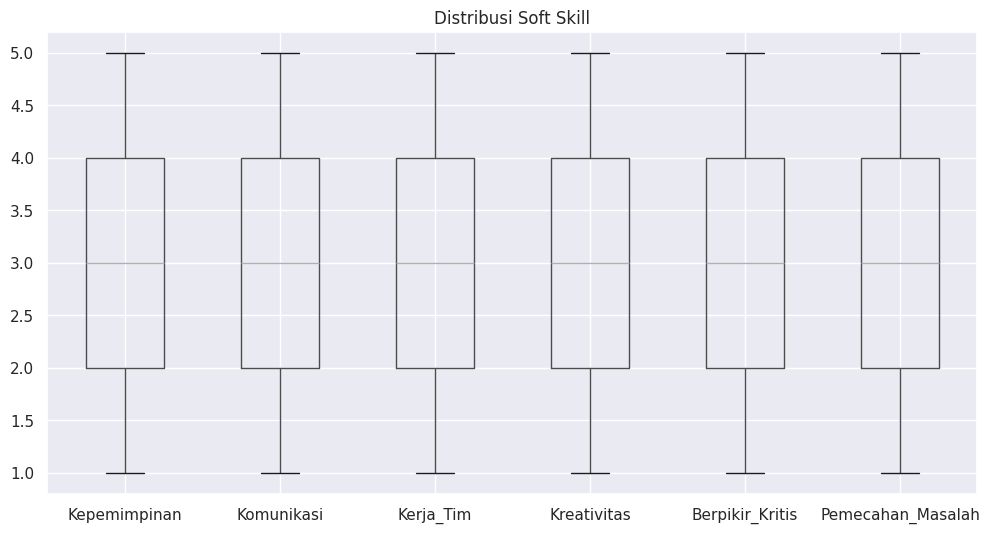

In [ ]:
plt.figure(figsize=(12,6))

Career_Recommendation_Cleaned_df[
    softskill
].boxplot()

plt.title('Distribusi Soft Skill')

plt.show()

### Insight
Boxplot menunjukkan bahwa seluruh aspek soft skill (Kepemimpinan, Komunikasi, Kerja Tim, Kreativitas, Berpikir Kritis, dan Pemecahan Masalah) memiliki pola distribusi yang hampir identik. Median masing-masing soft skill berada di sekitar nilai 3, dengan rentang nilai dari 1 hingga 5. Sebanyak 50% data berada pada rentang 2–4 (IQR), yang menunjukkan tingkat variasi yang moderat pada setiap aspek. Tidak terlihat adanya outlier yang signifikan, sehingga distribusi kemampuan soft skill mahasiswa relatif konsisten dan seimbang di seluruh kategori yang dianalisis.

## Analisis Pengalaman Mahasiswa

### Pengalaman Magang

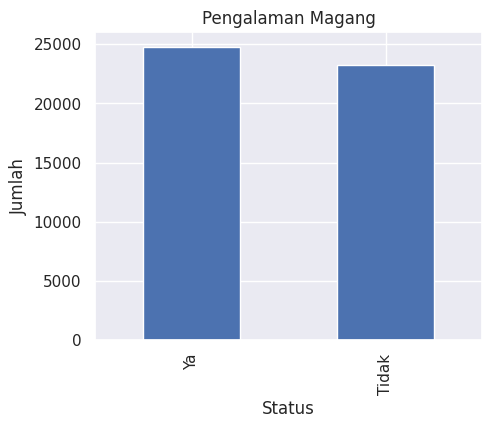

In [ ]:
plt.figure(figsize=(5,4))

Career_Recommendation_Cleaned_df['Pengalaman_Magang'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Pengalaman Magang')
plt.xlabel('Status')
plt.ylabel('Jumlah')

plt.show()

### Insight
Sebagian besar mahasiswa memiliki pengalaman magang. Hal ini menunjukkan tingkat keterlibatan mahasiswa dalam dunia kerja profesional sebelum menyelesaikan pendidikan.

### Pengalaman Organisasi


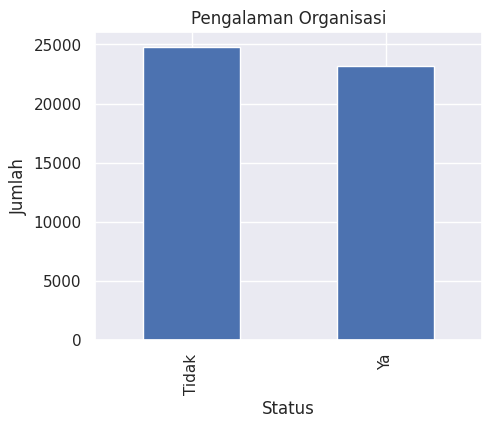

In [ ]:
plt.figure(figsize=(5,4))

Career_Recommendation_Cleaned_df['Pengalaman_Organisasi'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Pengalaman Organisasi')
plt.xlabel('Status')
plt.ylabel('Jumlah')

plt.show()

### Insight
Mayoritas mahasiswa tidak memiliki pengalaman organisasi. Kondisi ini menunjukkan tingkat partisipasi mahasiswa dalam kegiatan non-akademik yang dapat membantu pengembangan soft skill dan kemampuan kepemimpinan.

### Pengalaman Kompetisi

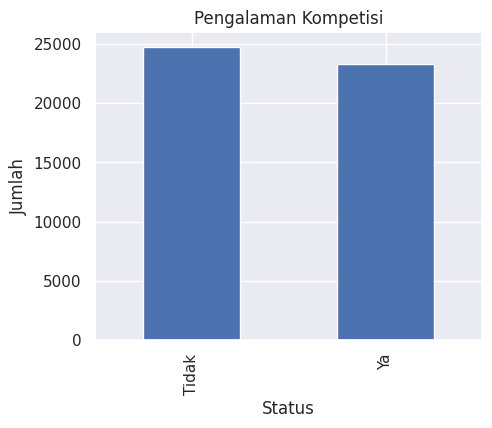

In [ ]:
plt.figure(figsize=(5,4))

Career_Recommendation_Cleaned_df['Pengalaman_Kompetisi'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Pengalaman Kompetisi')
plt.xlabel('Status')
plt.ylabel('Jumlah')

plt.show()

### Insight
Mayoritas mahasiswa belum pernah mengikuti kompetisi, meskipun perbedaannya tidak terlalu signifikan dibandingkan mahasiswa yang pernah mengikuti kompetisi. Hal ini menunjukkan bahwa partisipasi dalam kegiatan kompetitif cukup baik, namun masih terdapat peluang untuk meningkatkan keterlibatan mahasiswa dalam ajang kompetisi.

## Analisis Jumlah Sertifikasi

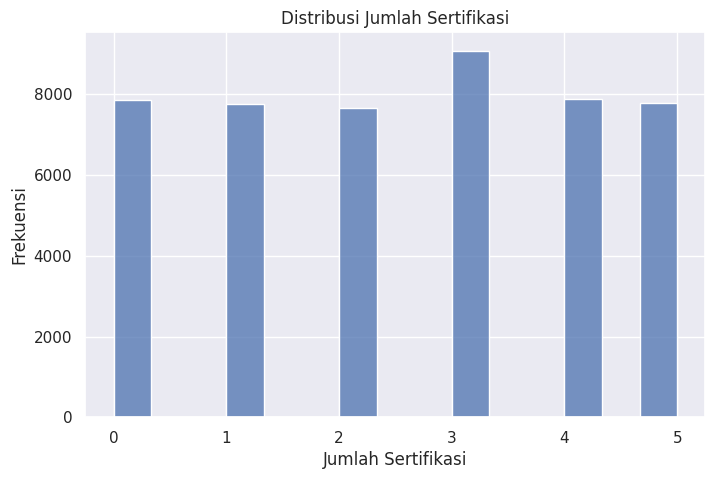

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=Career_Recommendation_Cleaned_df,
    x='Jumlah_Sertifikasi',
    bins=15
)

plt.title('Distribusi Jumlah Sertifikasi')
plt.xlabel('Jumlah Sertifikasi')
plt.ylabel('Frekuensi')

plt.show()

### Insight
Mayoritas mahasiswa memiliki sekitar 3 sertifikasi, dengan distribusi jumlah sertifikasi yang relatif merata pada setiap kategori. Hal ini menunjukkan bahwa cukup banyak mahasiswa yang aktif mengikuti pelatihan atau program sertifikasi untuk meningkatkan kompetensi mereka, meskipun masih terdapat sebagian mahasiswa dengan jumlah sertifikasi yang rendah yang berpotensi untuk didorong mengikuti lebih banyak program pengembangan keterampilan.

## Analisis Tujuan Karir

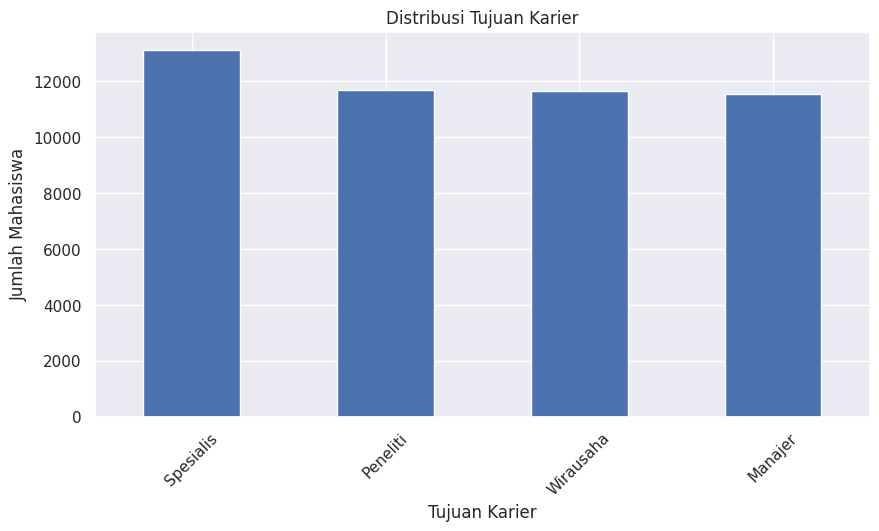

In [ ]:
plt.figure(figsize=(10,5))

Career_Recommendation_Cleaned_df['Tujuan_Karier'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Distribusi Tujuan Karier')
plt.xlabel('Tujuan Karier')
plt.ylabel('Jumlah Mahasiswa')

plt.xticks(rotation=45)

plt.show()

### Insight
Mayoritas mahasiswa memilih jalur karier sebagai Spesialis, sementara Manajer menjadi pilihan yang paling sedikit diminati. Distribusi yang relatif merata menunjukkan bahwa mahasiswa memiliki preferensi karier yang beragam, dengan kecenderungan lebih besar pada pengembangan keahlian profesional dan teknis di bidang tertentu.

## Analisis Rekomendasi Karir

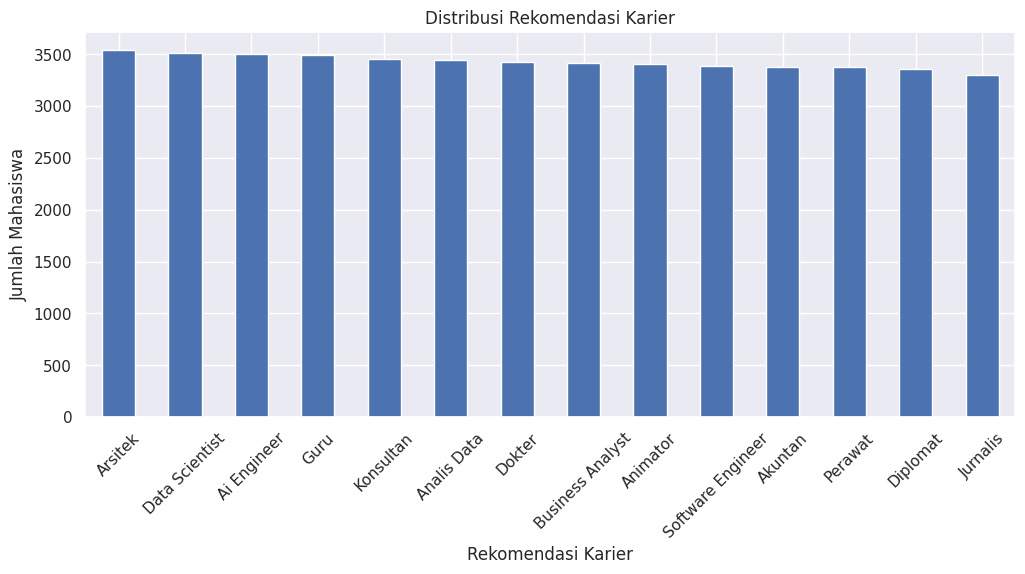

In [ ]:
plt.figure(figsize=(12,5))

Career_Recommendation_Cleaned_df['Rekomendasi_Karier'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Distribusi Rekomendasi Karier')
plt.xlabel('Rekomendasi Karier')
plt.ylabel('Jumlah Mahasiswa')

plt.xticks(rotation=45)

plt.show()

### Insight
Berdasarkan visualisasi distribusi rekomendasi karier, setiap kategori karier memiliki jumlah data yang relatif seimbang. Kondisi ini menunjukkan bahwa dataset telah mencakup berbagai jalur karier secara proporsional. Keseimbangan distribusi target seperti ini sangat baik untuk digunakan sebagai dasar pengembangan model AI karena dapat membantu model mempelajari setiap kategori karier dengan representasi data yang memadai.

## Analisis Korelasi Antar Fitur Numerik


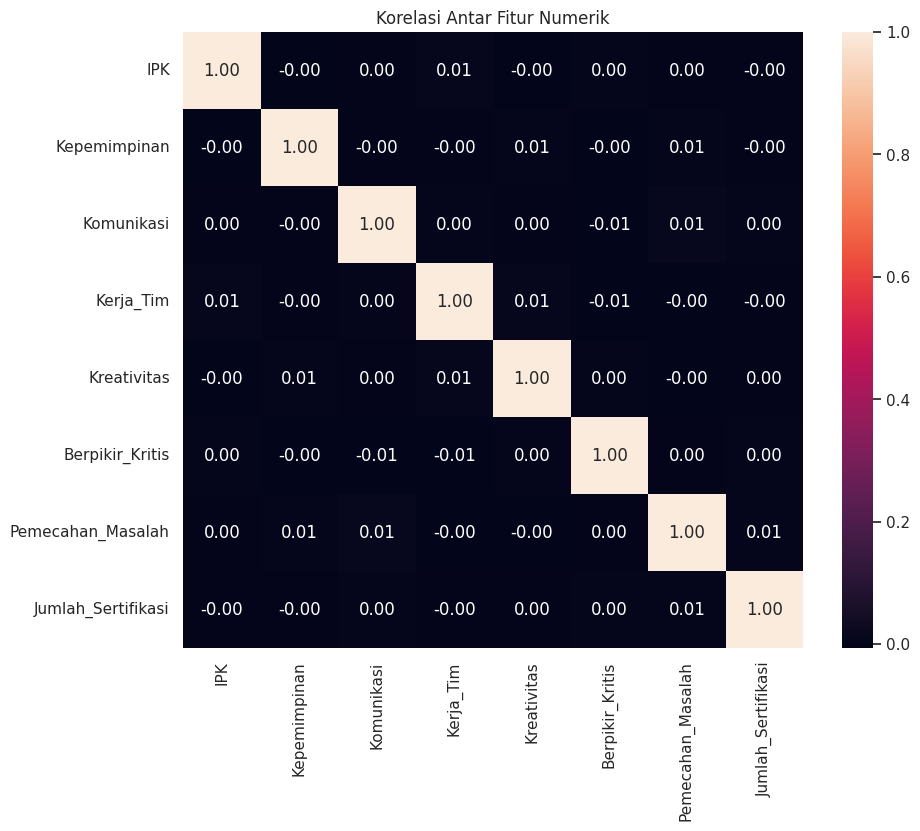

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    Career_Recommendation_Cleaned_df
        .select_dtypes(include='number')
        .corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Korelasi Antar Fitur Numerik')

plt.show()

### Insight
Seluruh fitur numerik menunjukkan nilai korelasi yang sangat rendah (mendekati 0). Hal ini mengindikasikan bahwa tidak terdapat hubungan linear yang kuat antar variabel numerik dalam dataset. Dengan kata lain, setiap fitur seperti IPK, kemampuan soft skill, dan jumlah sertifikasi cenderung memberikan informasi yang berbeda dan saling melengkapi.

## Hubungan Jurusan dengan Rekomendasi Karir

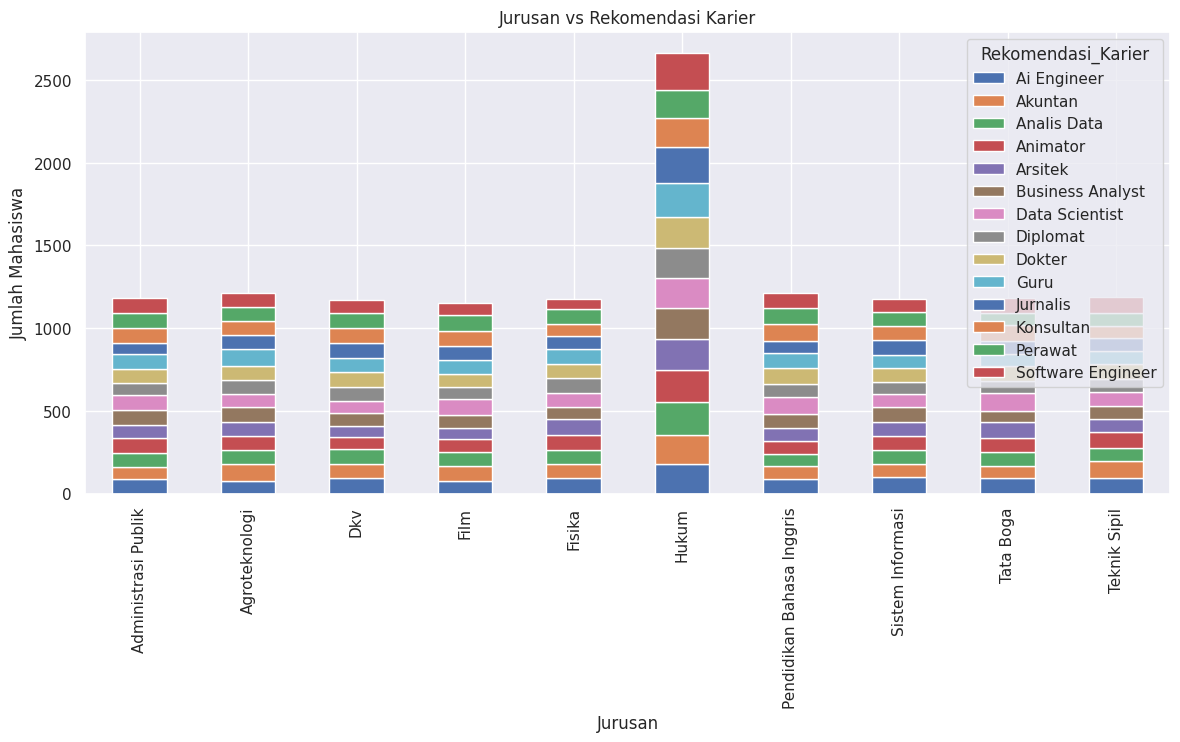

In [ ]:
top_jurusan = (
    Career_Recommendation_Cleaned_df['Jurusan']
    .value_counts()
    .head(10)
    .index
)

cross = pd.crosstab(
    Career_Recommendation_Cleaned_df[
        Career_Recommendation_Cleaned_df['Jurusan'].isin(top_jurusan)
    ]['Jurusan'],
    Career_Recommendation_Cleaned_df[
        Career_Recommendation_Cleaned_df['Jurusan'].isin(top_jurusan)
    ]['Rekomendasi_Karier']
)

cross.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title('Jurusan vs Rekomendasi Karier')
plt.xlabel('Jurusan')
plt.ylabel('Jumlah Mahasiswa')

plt.show()

### Insight
Setiap jurusan memiliki rekomendasi karier yang beragam, menunjukkan bahwa rekomendasi karier tidak hanya dipengaruhi oleh jurusan, tetapi juga oleh faktor lain seperti minat, soft skill, pengalaman, dan sertifikasi. Jurusan Hukum memiliki jumlah rekomendasi tertinggi karena jumlah mahasiswanya lebih banyak dibanding jurusan lainnya.

## Kesimpulan EDA
Berdasarkan hasil eksplorasi data, dataset menunjukkan keragaman yang baik dari sisi jurusan, bidang minat, pengalaman, soft skill, serta tujuan karier. Sebagian besar mahasiswa memiliki profil akademik dan non-akademik yang beragam, sehingga memberikan representasi yang cukup komprehensif untuk pengembangan sistem rekomendasi karier. Analisis korelasi menunjukkan bahwa beberapa kemampuan memiliki hubungan yang saling mendukung, sementara distribusi rekomendasi karier memperlihatkan variasi jalur karier yang dapat direkomendasikan berdasarkan karakteristik mahasiswa. Dataset ini telah siap digunakan sebagai dasar pengembangan model oleh tim AI.